# **[PROJECT 1] Day4 — LangGraph 기반 에이전틱 워크플로**

============================================================  
[프로젝트] 2026년 2차 서울시 청년안심주택(공공임대) 청약 도우미  
------------------------------------------------------------  
| 일차 | 역할 | 데이터 |
|------|------|--------|
| day2 | PDF 공고문 RAG | 모집공고문 PDF (Qdrant) |
| day3 | 테이블 Text2SQL | CSV 3종 (SQLite/Supabase) |
| **day4** | **의도 라우팅 에이전트** | RAG + Text2SQL 통합 |

08 `LangGraph essentials`(State · Node · Edge)와  
09 `conditional edges`(의도 분류 후 분기)를 같은 방식으로 적용합니다.

## 과제 진행 단계
1. **에이전트 목적 및 결과물 설계** — Use Case 정의
2. **시스템에 필요한 단계 정의** — 베이스라인 대비 추가 노드
3. **노드와 엣지 추가 및 고도화** — 조건부 라우팅 + 재시도 루프

## 0. 환경 설정

In [1]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv, find_dotenv

dotenv_path = find_dotenv(usecwd=True)
if dotenv_path:
    load_dotenv(dotenv_path, override=True)
    print(f"✓ .env 로드: {dotenv_path}")
else:
    load_dotenv()

print("\n=== 환경 변수 확인 ===")
print("✓ OpenAI API Key" if os.environ.get("OPENAI_API_KEY") else "✗ OPENAI_API_KEY 없음")
print("✓ Qdrant" if os.environ.get("QDRANT_URL") and os.environ.get("QDRANT_API_KEY") else "✗ Qdrant 미설정")
print("✓ Supabase DB URL" if os.environ.get("SUPABASE_DB_URL") else "- SUPABASE_DB_URL (SQLite fallback 가능)")

✓ .env 로드: c:\Users\LG\Documents\26-smu-ai-bootcamp\.env

=== 환경 변수 확인 ===
✓ OpenAI API Key
✓ Qdrant
✓ Supabase DB URL


In [2]:
CWD = Path.cwd().resolve()
REPO_ROOT = CWD if (CWD / "src" / "ai").exists() else CWD.parent
SRC_DIR = REPO_ROOT / "src"
sys.path.insert(0, str(SRC_DIR))

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"src 경로 추가: {SRC_DIR}")

REPO_ROOT: C:\Users\LG\Documents\26-smu-ai-bootcamp
src 경로 추가: C:\Users\LG\Documents\26-smu-ai-bootcamp\src


---

# 1. 에이전트 목적 및 결과물 설계

## 해결하려는 문제
66페이지 공고문과 단지·자격 표가 흩어져 있어, 지원자가 일정·자격·임대조건·서류를 한 번에 찾기 어렵습니다.
질문은 **문서 조항(RAG)** 과 **숫자/표 조회(Text2SQL)** 로 나뉘므로 의도를 먼저 분류한 뒤 경로를 나눕니다.

## 결과물
- LangGraph 에이전트 (`src/ai`)
- 이 노트북에서 그래프 컴파일 · 시각화 · 경로별 테스트

In [3]:
PROJECT_TOPIC = "2026년 2차 서울시 청년안심주택(공공임대) 청약 도우미"

USE_CASES = [
    {"intent": "general", "name": "서비스 안내", "question": "안녕하세요, 뭘 물어볼 수 있나요?"},
    {"intent": "vector", "name": "청약 일정", "question": "청약 접수는 언제부터 언제까지인가요?"},
    {"intent": "vector", "name": "제출서류", "question": "청년 2순위로 신청하려면 어떤 서류가 필요한가요?"},
    {"intent": "vector", "name": "유의사항", "question": "반려동물 키울 수 있나요?"},
    {"intent": "database", "name": "단지 임대조건", "question": "에이트플레이스 39A 타입 신혼Ⅰ 임대보증금과 월세는 얼마인가요?"},
    {"intent": "database", "name": "자격요건 표", "question": "청년 1순위 자격요건에 해당하는 경우는 어떤 경우들이 있나요?"},
    {"intent": "database", "name": "문의처", "question": "청년안심주택 민간임대 계약 관련해서 어디로 전화해야 하나요?"},
]

print(f"프로젝트: {PROJECT_TOPIC}\n")
for i, uc in enumerate(USE_CASES, 1):
    print(f"{i}. [{uc['intent']}] {uc['name']}")
    print(f"   Q. {uc['question']}")

프로젝트: 2026년 2차 서울시 청년안심주택(공공임대) 청약 도우미

1. [general] 서비스 안내
   Q. 안녕하세요, 뭘 물어볼 수 있나요?
2. [vector] 청약 일정
   Q. 청약 접수는 언제부터 언제까지인가요?
3. [vector] 제출서류
   Q. 청년 2순위로 신청하려면 어떤 서류가 필요한가요?
4. [vector] 유의사항
   Q. 반려동물 키울 수 있나요?
5. [database] 단지 임대조건
   Q. 에이트플레이스 39A 타입 신혼Ⅰ 임대보증금과 월세는 얼마인가요?
6. [database] 자격요건 표
   Q. 청년 1순위 자격요건에 해당하는 경우는 어떤 경우들이 있나요?
7. [database] 문의처
   Q. 청년안심주택 민간임대 계약 관련해서 어디로 전화해야 하나요?


---

# 2. 시스템에 필요한 단계 정의

09의 의도 분류 챗봇 베이스라인(`analyze_intent` → 응답 노드 → END)에서 아래를 추가합니다.

| 단계 | 노드 | 왜 필요한가 |
|------|------|-------------|
| 의도 분류 | `classify_intent` | 인사 / DB 수치 / 공고문 조항을 갈라야 함 |
| 일반 응답 | `general_answer` | RAG·SQL 없이 바로 답 |
| 문서 검색 | `vector_search` | day2 Qdrant + 카테고리 필터 |
| 쿼리 재작성 | `rewrite_query` | 검색 실패 시 한 번 더 시도 |
| 표 조회 | `database_query` | day3 Text2SQL, 오류 시 재시도 |
| 최종 답변 | `generate_answer` | 검색/SQL 근거를 자연어로 정리 |

```
__start__
   ↓
classify_intent
   ├── general_answer → __end__
   ├── database_query ↺ → generate_answer → __end__
   └── vector_search ↔ rewrite_query
              ↓
         generate_answer → __end__
```

## 2-1. Text2SQL용 Supabase 테이블 확인

CSV 파일 대신 Supabase(PostgreSQL)에 적재해 둔 `apartment`, `preferences`, `service_center`(이번 공고 전용) + `information`(전국 지자체별 청년주택 지원정보) 테이블을 그대로 사용합니다.

In [4]:
import os
from langchain_community.utilities import SQLDatabase

SUPABASE_DB_URL = os.getenv("SUPABASE_DB_URL")
if not SUPABASE_DB_URL:
    raise ValueError(
        "SUPABASE_DB_URL이 설정되어 있지 않습니다. "
        ".env에 apartment/preferences/service_center/information 테이블이 있는 "
        "Supabase PostgreSQL 연결 문자열을 설정하세요."
    )

REQUIRED_TABLES = ["apartment", "preferences", "service_center", "information"]

db = SQLDatabase.from_uri(SUPABASE_DB_URL)
available_tables = db.get_usable_table_names()

missing = [t for t in REQUIRED_TABLES if t not in available_tables]
if missing:
    raise RuntimeError(
        f"Supabase에서 다음 테이블을 찾을 수 없습니다: {missing}. "
        f"현재 확인된 테이블: {available_tables}"
    )

print(f"✓ Supabase 연결 확인 완료")
print(f"✓ 필수 테이블 확인 완료: {REQUIRED_TABLES}")
print(f"  (Supabase 내 전체 테이블: {available_tables})")

for table in REQUIRED_TABLES:
    count = db.run(f"SELECT COUNT(*) FROM {table};")
    print(f"  - {table}: {count}")


C:\Users\LG\AppData\Local\Temp\ipykernel_16188\2849368147.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


✓ Supabase 연결 확인 완료
✓ 필수 테이블 확인 완료: ['apartment', 'preferences', 'service_center', 'information']
  (Supabase 내 전체 테이블: ['apartment', 'information', 'preferences', 'service_center'])
  - apartment: [(182,)]
  - preferences: [(89,)]
  - service_center: [(8,)]
  - information: [(42,)]


---

# 3. 노드와 엣지 추가 및 고도화

## 3-1. State (08 essentials)

`MessagesState`로 대화 히스토리를 누적하고, 검색·SQL 중간값을 필드로 둡니다.

In [5]:
from ai.state import AgentState, InputState

print("AgentState 필드:")
for name, typ in AgentState.__annotations__.items():
    print(f"  - {name}: {typ}")

AgentState 필드:
  - messages: ForwardRef('Annotated[list[AnyMessage], add_messages]', module='langgraph.graph.message')
  - question: typing.Optional[str]
  - intent: typing.Optional[str]
  - vector_results: typing.Optional[list]
  - rewritten_query: typing.Optional[str]
  - sql_query: typing.Optional[str]
  - db_results: typing.Optional[str]
  - retry_count: typing.Optional[int]
  - error: typing.Optional[str]


## 3-2. 노드와 라우팅 함수 (09 conditional edges)

구현은 `src/ai/nodes.py`에 있습니다. 노트북에서는 그래프를 08·09와 같이 조립합니다.

In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage

from ai.nodes import (
    classify_intent,
    general_answer,
    vector_search,
    database_query,
    rewrite_query,
    generate_answer,
    route_by_intent,
    check_vector_results,
    check_db_results,
)

graph_builder = StateGraph(AgentState, input=InputState)

graph_builder.add_node("classify_intent", classify_intent)
graph_builder.add_node("general_answer", general_answer)
graph_builder.add_node("vector_search", vector_search)
graph_builder.add_node("database_query", database_query)
graph_builder.add_node("rewrite_query", rewrite_query)
graph_builder.add_node("generate_answer", generate_answer)

graph_builder.add_edge(START, "classify_intent")

graph_builder.add_conditional_edges(
    "classify_intent",
    route_by_intent,
    {
        "general_answer": "general_answer",
        "database_query": "database_query",
        "vector_search": "vector_search",
    },
)

graph_builder.add_edge("general_answer", END)

graph_builder.add_conditional_edges(
    "vector_search",
    check_vector_results,
    {
        "generate_answer": "generate_answer",
        "rewrite_query": "rewrite_query",
    },
)
graph_builder.add_edge("rewrite_query", "vector_search")

graph_builder.add_conditional_edges(
    "database_query",
    check_db_results,
    {
        "generate_answer": "generate_answer",
        "database_query": "database_query",
    },
)

graph_builder.add_edge("generate_answer", END)

graph = graph_builder.compile()
print("✓ 그래프 컴파일 완료")

✓ 그래프 컴파일 완료


C:\Users\LG\AppData\Local\Temp\ipykernel_16188\3727775578.py:16: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  graph_builder = StateGraph(AgentState, input=InputState)


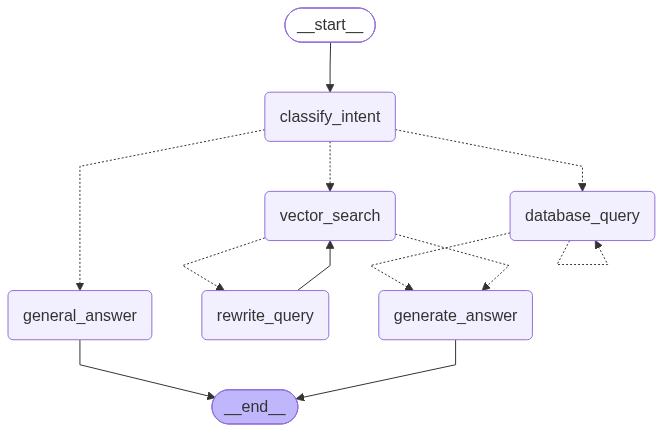

In [7]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("시각화 생략:", e)
    print(graph.get_graph().draw_mermaid())

## 3-3. 경로별 테스트

`invoke`로 한 경로씩 확인하고, 의도와 최종 답변을 출력합니다.

In [8]:
def run_agent(question: str):
    result = graph.invoke({"messages": [HumanMessage(content=question)]})
    answer = result["messages"][-1].content
    print(f"Q. {question}")
    print(f"intent: {result.get('intent')}")
    if result.get("sql_query"):
        print(f"SQL:\n{result['sql_query']}")
    if result.get("rewritten_query"):
        print(f"rewritten_query: {result['rewritten_query']}")
    n_docs = len(result.get("vector_results") or [])
    if n_docs:
        print(f"vector_results: {n_docs}개")
    print(f"A. {answer}\n")
    print("-" * 60)
    return result

In [9]:
# 경로 1) general_answer → END
run_agent("안녕하세요, 뭘 물어볼 수 있나요?")

Q. 안녕하세요, 뭘 물어볼 수 있나요?
intent: general
A. 안녕하세요! 무엇이든 편하게 물어보셔도 됩니다. 예를 들면:

- **정보 찾기**: 역사, 과학, 기술, 뉴스 요약
- **글쓰기 도움**: 이메일, 자기소개서, 보고서, 문장 다듬기
- **번역/외국어**: 한국어 ↔ 영어/일본어 등 번역, 표현 교정
- **공부 도움**: 문제 풀이, 개념 설명, 요약 정리
- **코딩**: 코드 작성, 오류 해결, 알고리즘 설명
- **일상 도움**: 일정 정리, 아이디어 브레인스토밍, 여행 계획
- **대화/조언**: 고민 정리, 선택지 비교, 말투 조언

원하시면 바로 시작해볼까요?  
예: **“영어 이메일을 정중하게 써줘”**, **“파이썬 오류를 봐줘”**, **“주식과 채권 차이를 쉽게 설명해줘”**

------------------------------------------------------------


{'messages': [HumanMessage(content='안녕하세요, 뭘 물어볼 수 있나요?', additional_kwargs={}, response_metadata={}, id='b4c60ed5-5c03-4fd0-803a-695820a609b6'),
  AIMessage(content='안녕하세요! 무엇이든 편하게 물어보셔도 됩니다. 예를 들면:\n\n- **정보 찾기**: 역사, 과학, 기술, 뉴스 요약\n- **글쓰기 도움**: 이메일, 자기소개서, 보고서, 문장 다듬기\n- **번역/외국어**: 한국어 ↔ 영어/일본어 등 번역, 표현 교정\n- **공부 도움**: 문제 풀이, 개념 설명, 요약 정리\n- **코딩**: 코드 작성, 오류 해결, 알고리즘 설명\n- **일상 도움**: 일정 정리, 아이디어 브레인스토밍, 여행 계획\n- **대화/조언**: 고민 정리, 선택지 비교, 말투 조언\n\n원하시면 바로 시작해볼까요?  \n예: **“영어 이메일을 정중하게 써줘”**, **“파이썬 오류를 봐줘”**, **“주식과 채권 차이를 쉽게 설명해줘”**', additional_kwargs={}, response_metadata={}, id='8f441922-8eb6-4369-b1ed-7990d3a94738', tool_calls=[], invalid_tool_calls=[])],
 'question': '안녕하세요, 뭘 물어볼 수 있나요?',
 'intent': 'general'}

In [10]:
# 경로 2) vector_search (↔ rewrite_query) → generate_answer → END
run_agent("청약 접수는 언제부터 언제까지인가요?")

[벡터 검색 쿼리 분석]
  원본 쿼리: 청약 접수는 언제부터 언제까지인가요?
  최적화된 쿼리: 청약 접수 일정 접수 기간 시작일 종료일 언제부터 언제까지
  선택된 카테고리: ['공급일정', '신청접수']
Q. 청약 접수는 언제부터 언제까지인가요?
intent: vector
vector_results: 3개
A. 청약 접수는 **2026년 8월 11일(화) 오전 10시부터 2026년 8월 13일(목) 오후 5시까지**입니다.

- **대상:** 청년계층, 신혼부부 계층
- **접수 방법:** **인터넷 청약만 가능**
- **청약 주소:** **www.i-sh.co.kr/app**

------------------------------------------------------------


{'messages': [HumanMessage(content='청약 접수는 언제부터 언제까지인가요?', additional_kwargs={}, response_metadata={}, id='47da63e4-ae36-4f79-83c2-7f5f2a661991'),
  AIMessage(content='청약 접수는 **2026년 8월 11일(화) 오전 10시부터 2026년 8월 13일(목) 오후 5시까지**입니다.\n\n- **대상:** 청년계층, 신혼부부 계층\n- **접수 방법:** **인터넷 청약만 가능**\n- **청약 주소:** **www.i-sh.co.kr/app**', additional_kwargs={}, response_metadata={}, id='a097f34d-df2f-40e7-ba96-6b43728a2f0c', tool_calls=[], invalid_tool_calls=[])],
 'question': '청약 접수는 언제부터 언제까지인가요?',
 'intent': 'vector',
 'vector_results': [Document(metadata={'page': 5, 'source': '2026년_2차_청년안심주택_모집공고문', 'category': '공급일정', '_id': '0dd9f4c5-91e3-4f3e-b978-ae714417d5ee', '_collection_name': 'cheongnyeon_anshim_housing'}, page_content='※ 일정은 진행상황에 따라 변동 가능하며, 입주지정기간은 입주 가능한날로부터 30일 간\n\n■ 인터넷 청약신청 세부일정\n\n    대상자                접수일정              인터넷청약 주소\n\n    청년계층,\n                         2026.08.11.(화) 10:00 ~ 2026.08.13.(목) 17:00       www.i-sh.co.kr/app\n   신혼부부 계층\n\n\n※ 인터넷 청약 신청만 가능합니다.\n\n■ 

In [11]:
# 경로 3) database_query (재시도 가능) → generate_answer → END
run_agent("에이트플레이스 39A 타입 신혼Ⅰ 임대보증금과 월세는 얼마인가요?")

Q. 에이트플레이스 39A 타입 신혼Ⅰ 임대보증금과 월세는 얼마인가요?
intent: database
SQL:
SELECT
  "단지명",
  "평면유형(㎡)",
  "신청자격",
  "임대보증금_계(천원)",
  "월임대료(원)"
FROM apartment
WHERE "단지명" = '에이트플레이스'
  AND "평면유형(㎡)" = '39A'
  AND "신청자격" = '신혼Ⅰ'
LIMIT 10;
A. 에이트플레이스 **39A 타입 신혼Ⅰ**의 임대조건은 다음과 같습니다.

- **임대보증금:** **29,000천원**
- **월세:** **1,144천원**

원하시면 같은 단지의 **다른 타입(예: 39B, 49 등)** 임대조건도 바로 알려드릴게요.

------------------------------------------------------------


{'messages': [HumanMessage(content='에이트플레이스 39A 타입 신혼Ⅰ 임대보증금과 월세는 얼마인가요?', additional_kwargs={}, response_metadata={}, id='a5c593c1-2ede-4732-bfba-591a48b80647'),
  AIMessage(content='에이트플레이스 **39A 타입 신혼Ⅰ**의 임대조건은 다음과 같습니다.\n\n- **임대보증금:** **29,000천원**\n- **월세:** **1,144천원**\n\n원하시면 같은 단지의 **다른 타입(예: 39B, 49 등)** 임대조건도 바로 알려드릴게요.', additional_kwargs={}, response_metadata={}, id='efbbd342-81d3-426b-af6a-74d3b1215659', tool_calls=[], invalid_tool_calls=[])],
 'question': '에이트플레이스 39A 타입 신혼Ⅰ 임대보증금과 월세는 얼마인가요?',
 'intent': 'database',
 'sql_query': 'SELECT\n  "단지명",\n  "평면유형(㎡)",\n  "신청자격",\n  "임대보증금_계(천원)",\n  "월임대료(원)"\nFROM apartment\nWHERE "단지명" = \'에이트플레이스\'\n  AND "평면유형(㎡)" = \'39A\'\n  AND "신청자격" = \'신혼Ⅰ\'\nLIMIT 10;',
 'db_results': '',
 'retry_count': 2,
 'error': None}

In [12]:
run_agent("청년안심주택 민간임대 계약 관련해서 어디로 전화해야 하나요?")

Q. 청년안심주택 민간임대 계약 관련해서 어디로 전화해야 하나요?
intent: database
SQL:
SELECT "기관/부서명", "담당업무", "전화번호", "비고"
FROM service_center
WHERE "구분" = '민간임대'
ORDER BY "기관/부서명"
LIMIT 10;
A. 청년안심주택 **민간임대 계약 관련 문의**는 아래로 하시면 됩니다.

- **청년안심주택 종합지원센터(안심주택종합지원센터)**
  - **전화번호:** 02-793-0765~0768
  - **담당업무:** 민간임대 입주 전 안내, **계약**, 입주 중 문의, 퇴거까지 원스톱 상담

참고로, **개별 단지의 모집공고·계약·시설 문의**는 각 단지별 **입주지원센터**로 문의하시면 됩니다. 예를 들어 **구로디지털단지역 유벤투스 240**은 **02-855-2401**입니다.

------------------------------------------------------------


{'messages': [HumanMessage(content='청년안심주택 민간임대 계약 관련해서 어디로 전화해야 하나요?', additional_kwargs={}, response_metadata={}, id='e30cf2b4-d94d-437a-b5ac-ab531ed6b7f3'),
  AIMessage(content='청년안심주택 **민간임대 계약 관련 문의**는 아래로 하시면 됩니다.\n\n- **청년안심주택 종합지원센터(안심주택종합지원센터)**\n  - **전화번호:** 02-793-0765~0768\n  - **담당업무:** 민간임대 입주 전 안내, **계약**, 입주 중 문의, 퇴거까지 원스톱 상담\n\n참고로, **개별 단지의 모집공고·계약·시설 문의**는 각 단지별 **입주지원센터**로 문의하시면 됩니다. 예를 들어 **구로디지털단지역 유벤투스 240**은 **02-855-2401**입니다.', additional_kwargs={}, response_metadata={}, id='55a7b6da-093d-4178-a8e6-8a876db02ce4', tool_calls=[], invalid_tool_calls=[])],
 'question': '청년안심주택 민간임대 계약 관련해서 어디로 전화해야 하나요?',
 'intent': 'database',
 'sql_query': 'SELECT "기관/부서명", "담당업무", "전화번호", "비고"\nFROM service_center\nWHERE "구분" = \'민간임대\'\nORDER BY "기관/부서명"\nLIMIT 10;',
 'db_results': "[('단지별 입주지원센터', '개별 단지의 모집공고·계약·시설 문의', '단지마다 상이 (예: 구로디지털단지역 유벤투스 240 - 02-855-2401)', '각 단지 모집공고문 하단에 개별 안내'), ('청년안심주택 종합지원센터(안심주택종합지원센터)', '민간임대 입주 전 안내·계약·입주중·퇴거 원스톱 서비스', '02-793-0765~0768',

## 3-4. 패키지 그래프와 동일성

LangGraph Studio는 `src/ai/graph.py:graph`를 사용합니다. 위 셀과 같은 워크플로입니다.

In [13]:
from ai.graph import create_graph

studio_graph = create_graph()
print("노드:", list(studio_graph.get_graph().nodes))
print("\n프로젝트 구조")
print("src/ai/")
print("  state.py      # AgentState")
print("  nodes.py      # classify / search / sql / answer")
print("  retriever.py  # Qdrant (cheongnyeon_anshim_housing)")
print("  text2sql.py   # apartment · preferences · service_center")
print("  graph.py      # 조건부 엣지 워크플로")

노드: ['__start__', 'classify_intent', 'general_answer', 'vector_search', 'database_query', 'rewrite_query', 'generate_answer', '__end__']

프로젝트 구조
src/ai/
  state.py      # AgentState
  nodes.py      # classify / search / sql / answer
  retriever.py  # Qdrant (cheongnyeon_anshim_housing)
  text2sql.py   # apartment · preferences · service_center
  graph.py      # 조건부 엣지 워크플로
